# Import libraries and data

In [46]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import Haver as hv
import pickle
from datetime import date
from datetime import datetime
from dateutil.relativedelta import relativedelta
from statsmodels.tsa.ar_model import AutoReg
from warnings import filterwarnings
import io, os, glob
import requests, zipfile
from statsmodels.tsa.seasonal import STL
from statsmodels.multivariate.pca import PCA
from statsmodels.tsa.filters.hp_filter import hpfilter
from numpy.linalg import inv
from scipy.stats import gaussian_kde

Import 1995-2023 HS4 export data:

In [47]:
# Path to file
file_path = "hs92_country_product_year_4.csv"

# Read CSV
hs4_exports = pd.read_csv(
    file_path,
    encoding="utf-8",          # adjust if file uses gbk/latin-1
    dtype=str                  # keeps HS codes and IDs as strings
)
hs4_exports['pci'] = hs4_exports['pci'].astype(float)

hs4_exports

,country_id,country_iso3_code,product_id,product_hs92_code,year,export_value,import_value,global_market_share,export_rca,distance,cog,pci
0,4,AFG,650,0101,2001,0,13440,0.0,0.0,0.939,0.002,3.20e-02
1,4,AFG,650,0101,2002,8767,1521,6e-06,0.622626,0.934,0.002,-8.00e-03
2,4,AFG,650,0101,2003,0,136545,0.0,0.0,0.941,0.002,3.33e-01
3,4,AFG,650,0101,2004,0,49566,0.0,0.0,0.938,0.001,2.06e-01
4,4,AFG,650,0101,2005,7220,26130,3e-06,0.166021,0.924,0.001,-2.94e-01
...,...,...,...,...,...,...,...,...,...,...,...,...
6497424,999,ANS,1829,9107,1995,0,5907,0.0,0.0,0.997,0.004,9.07e-01
6497425,999,ANS,1853,9401,1999,0,35680,0.0,0.0,0.998,0.0,-4.10e-02
6497426,999,ANS,1855,9403,1999,0,48930,0.0,0.0,0.998,0.0,-1.66e-01
6497427,999,ANS,1891,9999,1996,0,6182,0.0,0.0,0.992,0.001,-2.91e-01


# Export value density by complexity

Plot for China, Germany and Japan:

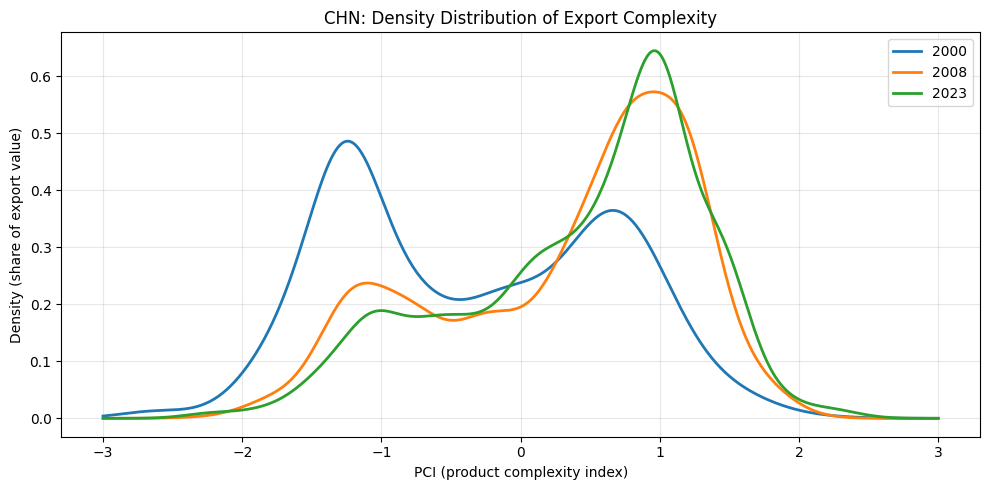

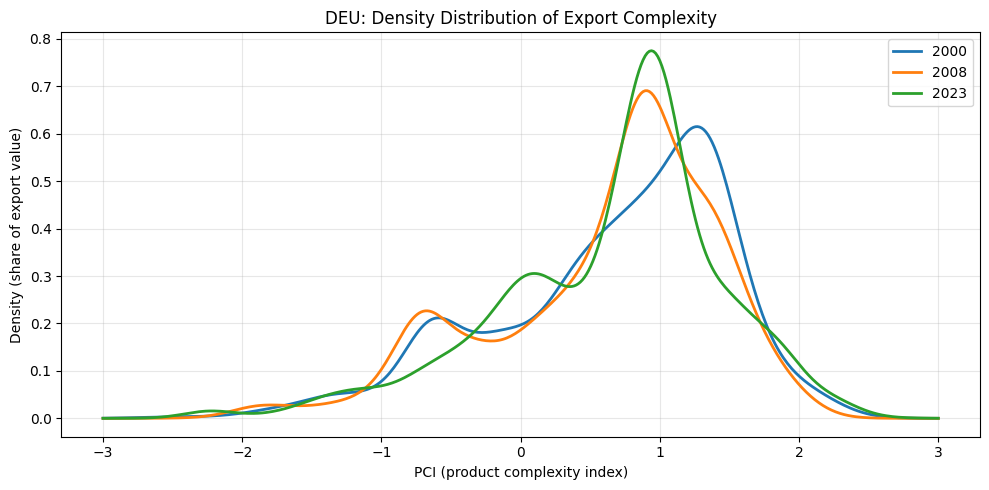

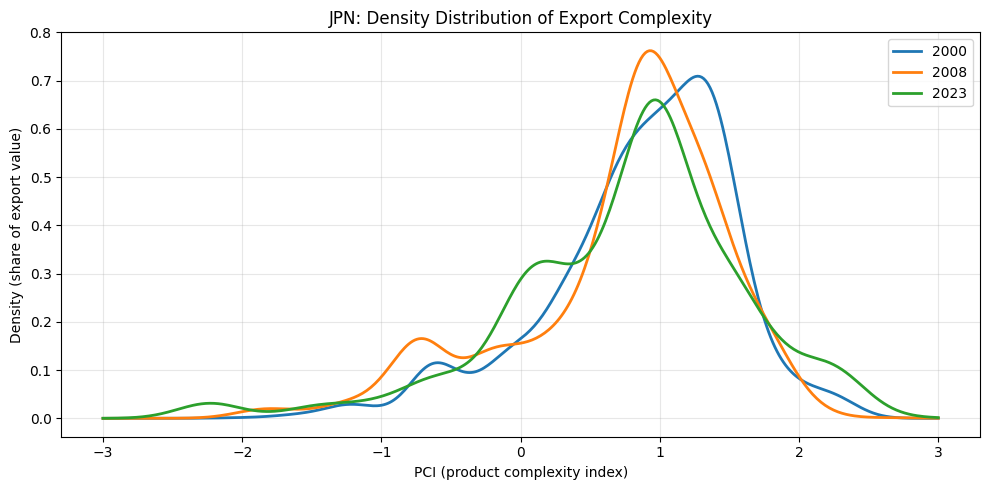

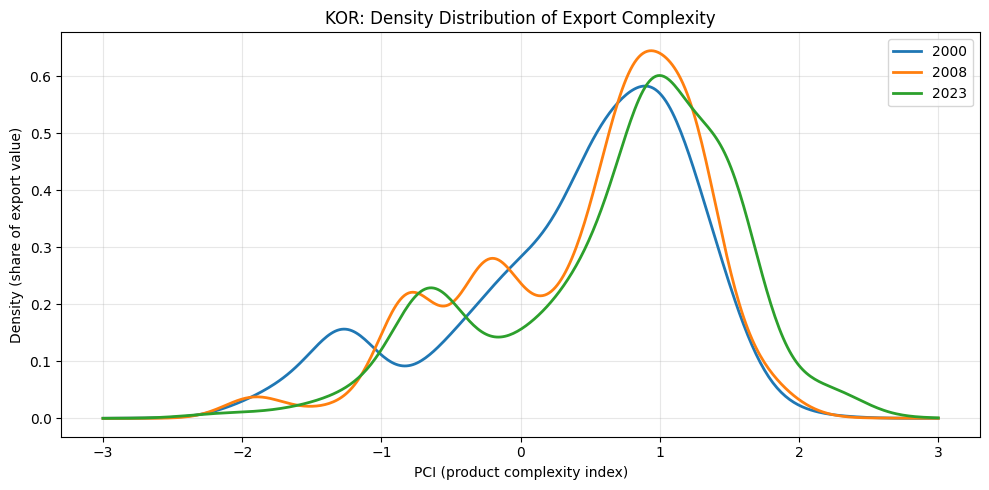

In [43]:
for country in ['CHN', 'DEU', 'JPN', 'KOR']:
    
    country_exports = hs4_exports[hs4_exports['country_iso3_code'] == country].copy()
    years = [2000, 2008, 2023]
    
    # Fixed PCI grid over [-3, 3]
    pci_grid = np.linspace(-3, 3, 400)
    
    # Create empty dict to store densities by year
    density_dict = {"pci_grid": pci_grid}
    
    plt.figure(figsize=(10,5))
    
    for year in years:
        # ---- 1. Filter for year ----
        df = country_exports[country_exports["year"] == str(year)].copy()
        df = df.replace([np.inf, -np.inf], np.nan)
        df = df.dropna(subset=["pci", "export_value"])
    
        # ---- 2. Truncate PCI ----
        df = df[(df["pci"] >= -3) & (df["pci"] <= 3)]
    
        # ---- 3. Extract data ----
        x = df["pci"].astype(float).values
        w = df["export_value"].astype(float).values
        w = w / w.sum()
    
        # ---- 4. Weighted KDE ----
        kde = gaussian_kde(x, weights=w)
        kde.set_bandwidth(bw_method=kde.factor * 0.5)
    
        # ---- 5. Evaluate KDE on fixed grid ----
        y_grid = kde(pci_grid)
    
        # ---- 6. Store as a column ----
        density_dict[f"density_{year}"] = y_grid
    
        # ---- 7. Plot ----
        plt.plot(pci_grid, y_grid, linewidth=2, label=f"{year}")
    
    plt.xlabel("PCI (product complexity index)")
    plt.ylabel("Density (share of export value)")
    plt.title(f"{country}: Density Distribution of Export Complexity")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Export value by complexity

Plot for China, Germany and Japan:

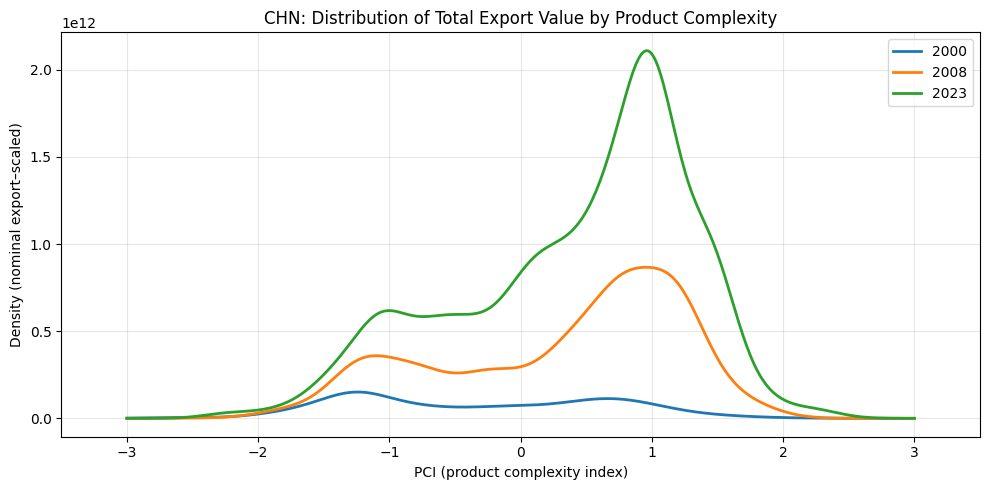

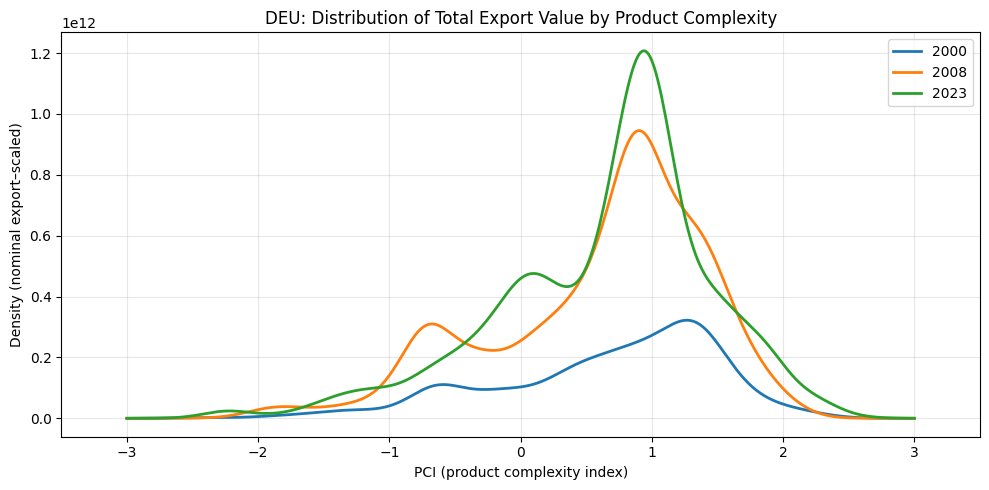

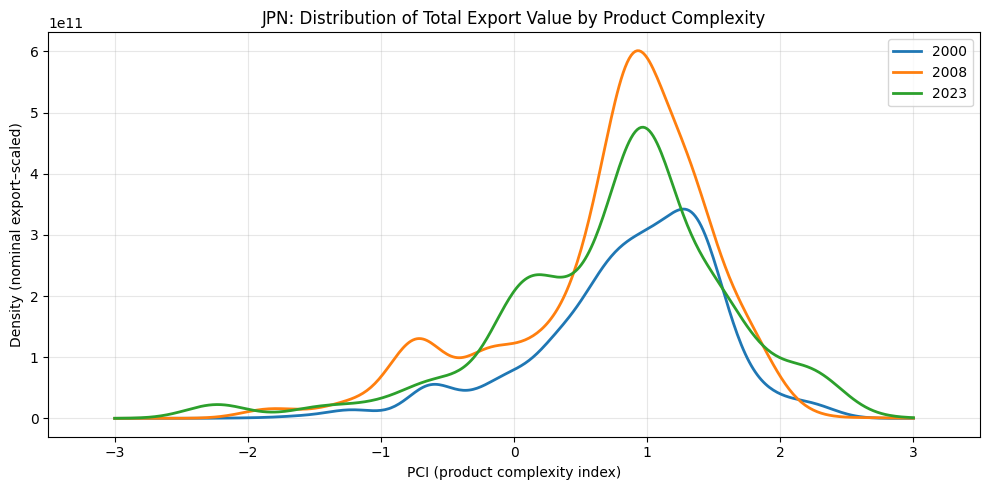

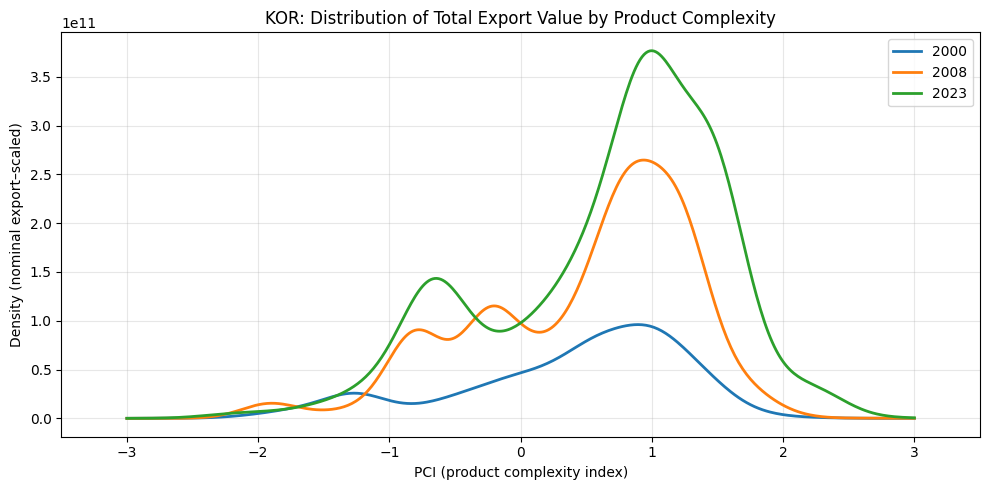

In [42]:
for country in ['CHN', 'DEU', 'JPN', 'KOR']:

    country_exports = hs4_exports[hs4_exports['country_iso3_code'] == country].copy()
    years = [2000, 2008, 2023]
    
    # --- Fixed PCI grid over [-3, 3] ---
    pci_grid = np.linspace(-3, 3, 400)
    
    # --- Dictionary that will become the output DataFrame ---
    value_dict = {"pci_grid": pci_grid}
    
    plt.figure(figsize=(10,5))
    
    for year in years:
        # ---- Filter ----
        df = country_exports[country_exports["year"] == str(year)].copy()
        df = df.replace([np.inf, -np.inf], np.nan)
        df = df.dropna(subset=["pci", "export_value"])
    
        # ---- TRUNCATE PCI RANGE ----
        df = df[(df["pci"] >= -3) & (df["pci"] <= 3)]
    
        # ---- Extract PCI ----
        x = df["pci"].astype(float).values
    
        # ---- Weights = nominal export values (NOT normalized) ----
        weights = df["export_value"].astype(float).values
        total_exports = weights.sum()
    
        # ---- KDE ----
        kde = gaussian_kde(x, weights=weights)
        kde.set_bandwidth(bw_method=kde.factor * 0.5)
    
        # ---- Evaluate KDE on fixed grid ----
        y_grid = kde(pci_grid)
    
        # ---- Scale KDE so that it integrates to total nominal exports ----
        y_grid = y_grid * total_exports
    
        # ---- Store column ----
        value_dict[f"value_{year}"] = y_grid
    
        # ---- Plot ----
        plt.plot(pci_grid, y_grid, linewidth=2, label=f"{year}")
    
    plt.xlabel("PCI (product complexity index)")
    plt.ylabel("Density (nominal export–scaled)")
    plt.title(f"{country}: Distribution of Total Export Value by Product Complexity")
    plt.grid(True, alpha=0.3)
    plt.xlim(-3.5, 3.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Global market share by complexity

Estimate for each country $c$ their share of global exports as a function of product complexity (PCI) using a nonparametric Nadaraya–Watson estimator. For each PCI value $x$, the estimated share is:

$$
\hat{s}(x)
=
\frac{\sum_{i=1}^N K_h(x - \text{PCI}_i)\, w^{c}_i}
     {\sum_{i=1}^N K_h(x - \text{PCI}_i)\, w^{WORLD}_i},
$$

where $\text{PCI}_i$ is the complexity of product $i$, $w^{c}_i$ is China's export value, $w^{WORLD}_i$ is the corresponding world export value, and $K_h(\cdot)$ is a Gaussian kernel with bandwidth $h$.

The numerator and denominator are kernel-smoothed export values for China and the world, respectively. Thus, $\hat{s}(x)$ represents the share of country $c$’s exports to global exports for goods with PCI near $x$.

In [48]:
# ---------------------------
# CLEAN THE DATA
# ---------------------------
df = hs4_exports.copy().replace([np.inf, -np.inf], np.nan)
df["pci"] = pd.to_numeric(df["pci"], errors="coerce")
df["export_value"] = pd.to_numeric(df["export_value"], errors="coerce")

# Truncate PCI range
df = df[(df["pci"] >= -3) & (df["pci"] <= 3)]
df = df.dropna(subset=["pci", "export_value"])

# ---------------------------
# SETTINGS
# ---------------------------
years = [2000, 2008, 2023]
bandwidth = 0.25

# Fixed PCI grid for final DataFrame
pci_grid = np.linspace(-2.5, 2.5, 100)

# Dictionary for final wide table
share_dict = {"pci_grid": pci_grid}

Plot for China, Germany and Japan:

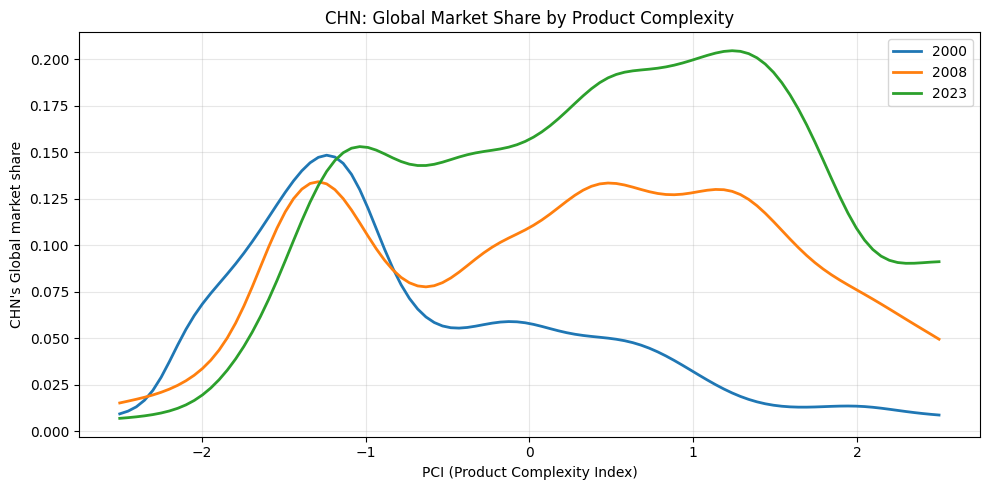

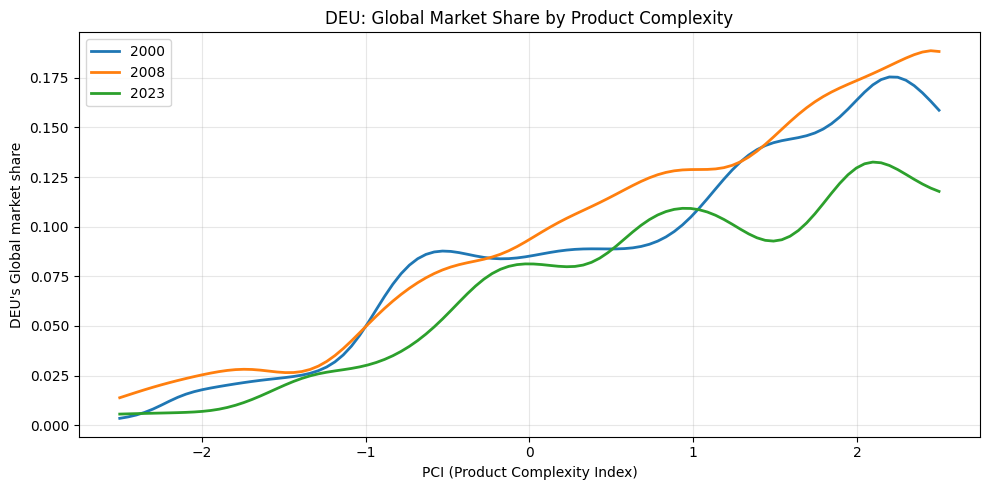

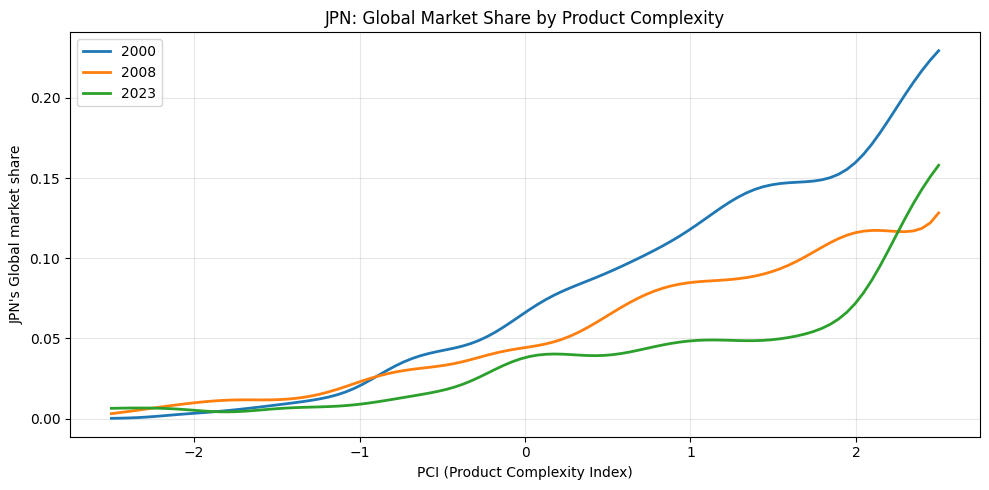

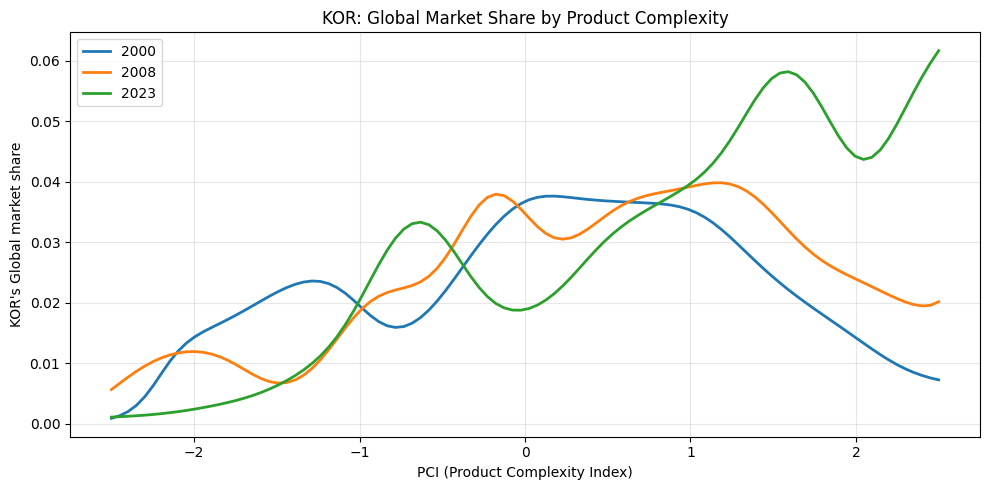

In [49]:
# ---------------------------
# PLOT SETUP
# ---------------------------
for country in ['CHN', 'DEU', 'JPN', 'KOR']:

    plt.figure(figsize=(10,5))
    
    # ---------------------------
    # LOOP OVER YEARS
    # ---------------------------
    for year in years:
    
        df_year = df[df["year"] == str(year)].copy()
        if df_year.empty:
            print(f"Skipping year {year}: no data.")
            continue
        
        # PCI values
        x_world = df_year["pci"].values
    
        # Global export weights
        w_world = df_year["export_value"].values
    
        # China export weights (0 for non-China)
        w_china = np.where(df_year["country_iso3_code"] == country,
                           df_year["export_value"].values,
                           0.0)
    
        # ---------------------------
        # FAST GAUSSIAN SMOOTHER
        # ---------------------------
        diff = pci_grid[:, None] - x_world[None, :]
        K = np.exp(-0.5 * (diff / bandwidth)**2)
    
        # Smoothed numerator (China exports)
        num_vals = K @ w_china
    
        # Smoothed denominator (global)
        den_vals = K @ w_world
        den_vals = np.clip(den_vals, 1e-12, None)
    
        # Smoothed share
        share_smooth = num_vals / den_vals
        share_smooth = np.clip(share_smooth, 0, 1)
    
        # ---------------------------
        # Store results
        # ---------------------------
        share_dict[f"share_{year}"] = share_smooth
    
        # Plot
        plt.plot(pci_grid, share_smooth, linewidth=2, label=f"{year}")
    
    # ---------------------------
    # FINAL FIGURE LABELS
    # ---------------------------
    plt.title(f"{country}: Global Market Share by Product Complexity")
    plt.xlabel("PCI (Product Complexity Index)")
    plt.ylabel(f"{country}'s Global market share")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()